# Global Population Data Visualization

This project analyzes global population distribution using the World Bank dataset.  
The objective is to explore population trends across countries through data cleaning, exploratory data analysis, and visualization using Python.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [22]:
import os
os.listdir("../data/raw")

['population.csv']

In [23]:
import pandas as pd

data_path = "../data/raw/population.csv"

df = pd.read_csv(data_path, skiprows=4)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (266, 70)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            264 non-null    float64
 5   1961            264 non-null    float64
 6   1962            264 non-null    float64
 7   1963            264 non-null    float64
 8   1964            264 non-null    float64
 9   1965            264 non-null    float64
 10  1966            264 non-null    float64
 11  1967            264 non-null    float64
 12  1968            264 non-null    float64
 13  1969            264 non-null    float64
 14  1970            264 non-null    float64
 15  1971            264 non-null    float64
 16  1972            264 non-null    float64
 17  1973            264 non-null    flo

In [25]:
df.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
count,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,...,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,2.650000e+02,0.0
mean,1.154023e+08,1.170070e+08,1.191678e+08,1.218381e+08,1.245322e+08,1.272581e+08,1.301037e+08,1.329570e+08,1.358851e+08,1.389115e+08,...,3.040350e+08,3.078574e+08,3.116049e+08,3.152801e+08,3.187967e+08,3.219557e+08,3.251253e+08,3.284356e+08,3.318869e+08,NaN
std,3.616526e+08,3.661347e+08,3.727681e+08,3.813687e+08,3.900162e+08,3.987697e+08,4.079989e+08,4.172145e+08,4.266937e+08,4.365313e+08,...,9.447450e+08,9.557617e+08,9.664403e+08,9.768047e+08,9.866025e+08,9.952966e+08,1.003734e+09,1.012519e+09,1.021734e+09,NaN
min,2.715000e+03,2.970000e+03,3.264000e+03,3.584000e+03,3.922000e+03,4.282000e+03,4.664000e+03,5.071000e+03,5.500000e+03,5.631000e+03,...,1.093000e+04,1.086900e+04,1.075100e+04,1.058100e+04,1.039900e+04,1.019400e+04,9.992000e+03,9.816000e+03,9.646000e+03,NaN
25%,5.152028e+05,5.255230e+05,5.363018e+05,5.475875e+05,5.593638e+05,5.675750e+05,5.711695e+05,5.779525e+05,5.825170e+05,5.861185e+05,...,1.777568e+06,1.791019e+06,1.797086e+06,1.788891e+06,1.790151e+06,1.786079e+06,1.803545e+06,1.827816e+06,1.792179e+06,NaN
50%,3.659633e+06,3.747132e+06,3.831900e+06,3.919710e+06,4.010150e+06,4.102976e+06,4.198738e+06,4.297792e+06,4.396290e+06,4.503420e+06,...,1.032545e+07,1.025915e+07,1.028382e+07,1.042338e+07,1.069786e+07,1.050577e+07,1.048694e+07,1.064485e+07,1.087698e+07,NaN
75%,2.686293e+07,2.761326e+07,2.837302e+07,2.915448e+07,2.995223e+07,3.075921e+07,3.147516e+07,3.203946e+07,3.247057e+07,3.277149e+07,...,6.011522e+07,6.000225e+07,6.014866e+07,5.972908e+07,6.097280e+07,6.283041e+07,6.471182e+07,6.661761e+07,6.851670e+07,NaN
max,3.021513e+09,3.062768e+09,3.117372e+09,3.184063e+09,3.251253e+09,3.318998e+09,3.389087e+09,3.459015e+09,3.530704e+09,3.604816e+09,...,7.529067e+09,7.614749e+09,7.697492e+09,7.778304e+09,7.855075e+09,7.920862e+09,7.990400e+09,8.064977e+09,8.142056e+09,NaN


In [26]:
# Remove unnecessary columns
df = df.drop(columns=["Indicator Name", "Indicator Code"], errors="ignore")

# Check dataset
df.head()


,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,58694.0,58990.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107624.0,NaN
1,Africa Eastern and Southern,AFE,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,153281203.0,157704381.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,769294618.0,NaN
2,Afghanistan,AFG,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,10266395.0,10505959.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN
3,Africa Western and Central,AFW,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,111246953.0,113795019.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN
4,Angola,AGO,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,5581386.0,5641807.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN


In [27]:
year_columns = [col for col in df.columns if col.isdigit()]

latest_year = max(year_columns)

print("Latest year available in dataset:", latest_year)

Latest year available in dataset: 2024


In [28]:
population_latest = df[["Country Name", latest_year]]

population_latest = population_latest.dropna()

population_latest = population_latest.sort_values(by=latest_year, ascending=False)

population_latest.head(10)

,Country Name,2024
259,World,8.142056e+09
103,IDA & IBRD total,6.926456e+09
140,Low & middle income,6.563720e+09
156,Middle income,5.939112e+09
102,IBRD only,4.979720e+09
62,Early-demographic dividend,3.552279e+09
139,Lower middle income,3.120984e+09
249,Upper middle income,2.818128e+09
63,East Asia & Pacific,2.388378e+09
142,Late-demographic dividend,2.328891e+09


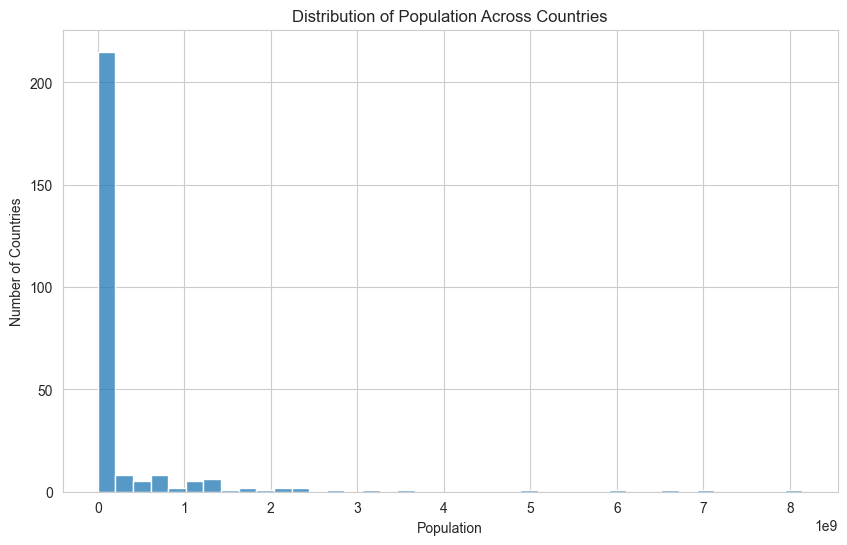

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(population_latest[latest_year], bins=40)

plt.title("Distribution of Population Across Countries")
plt.xlabel("Population")
plt.ylabel("Number of Countries")

plt.show()

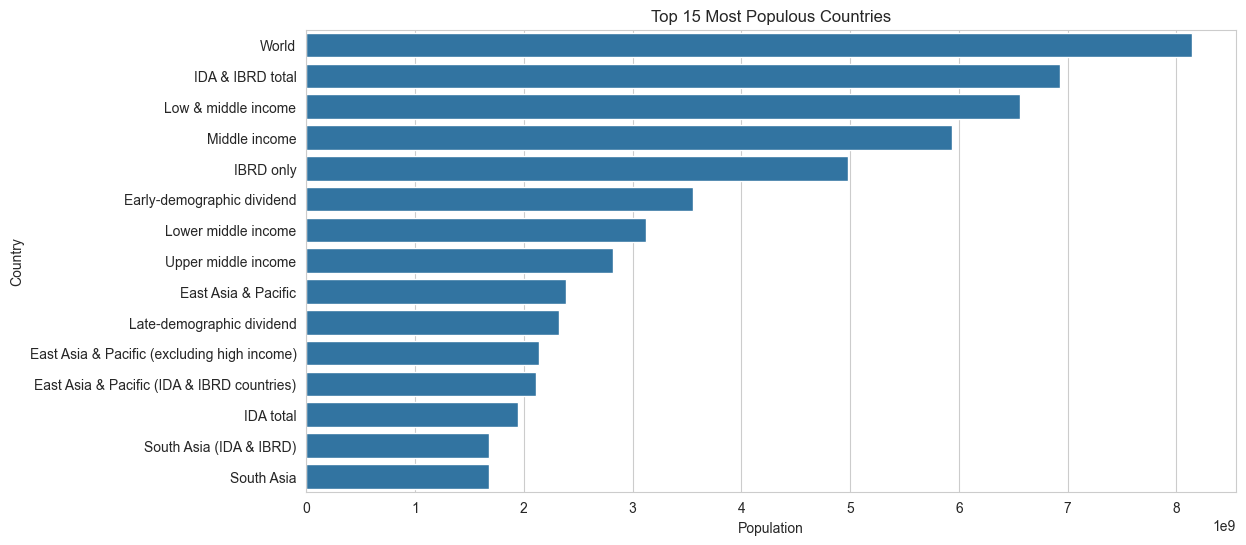

In [30]:
top15 = population_latest.head(15)

plt.figure(figsize=(12,6))

sns.barplot(x=latest_year, y="Country Name", data=top15)

plt.title("Top 15 Most Populous Countries")
plt.xlabel("Population")
plt.ylabel("Country")

plt.show()

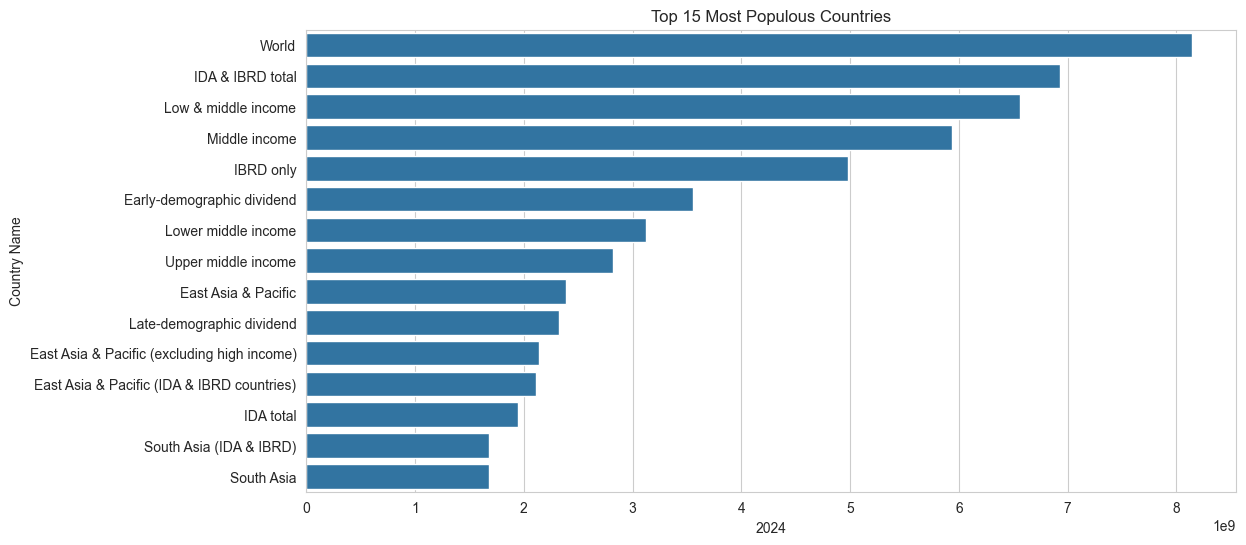

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(x=latest_year, y="Country Name", data=top15)

plt.title("Top 15 Most Populous Countries")

plt.savefig("../outputs/figures/top15_population.png", dpi=300)

plt.show()

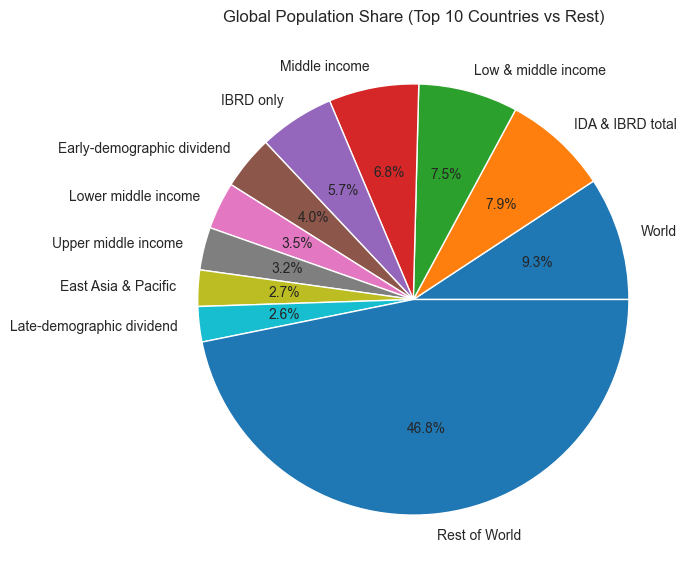

In [32]:
top10 = population_latest.head(10)

rest_population = population_latest[latest_year].sum() - top10[latest_year].sum()

labels = list(top10["Country Name"]) + ["Rest of World"]
values = list(top10[latest_year]) + [rest_population]

plt.figure(figsize=(10,7))

plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Global Population Share (Top 10 Countries vs Rest)")

plt.show()

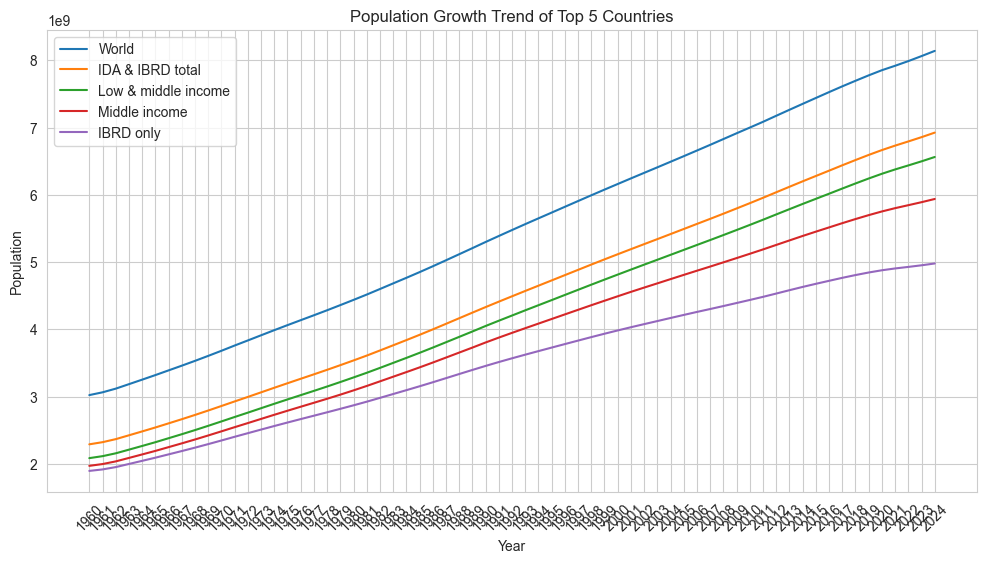

In [33]:
years = [col for col in df.columns if col.isdigit()]

top5 = population_latest.head(5)["Country Name"]

trend_data = df[df["Country Name"].isin(top5)]

plt.figure(figsize=(12,6))

for country in top5:
    country_data = trend_data[trend_data["Country Name"] == country]
    plt.plot(years, country_data[years].values[0], label=country)

plt.xticks(rotation=45)

plt.title("Population Growth Trend of Top 5 Countries")

plt.xlabel("Year")
plt.ylabel("Population")

plt.legend()

plt.show()

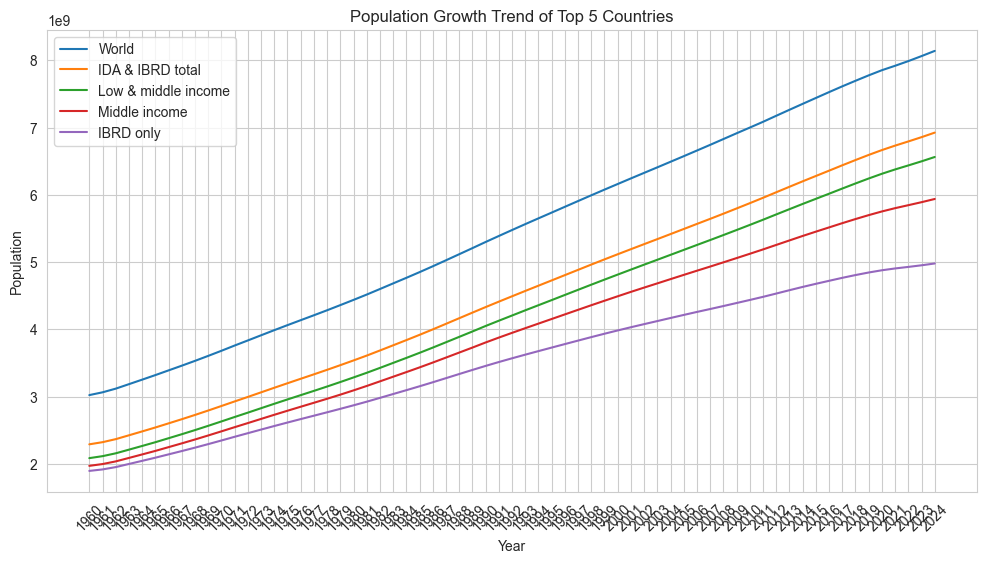

In [34]:
plt.figure(figsize=(12,6))

for country in top5:
    country_data = trend_data[trend_data["Country Name"] == country]
    plt.plot(years, country_data[years].values[0], label=country)

plt.xticks(rotation=45)

plt.title("Population Growth Trend of Top 5 Countries")

plt.xlabel("Year")
plt.ylabel("Population")

plt.legend()

plt.savefig("../outputs/figures/population_trend.png", dpi=300)

plt.show()

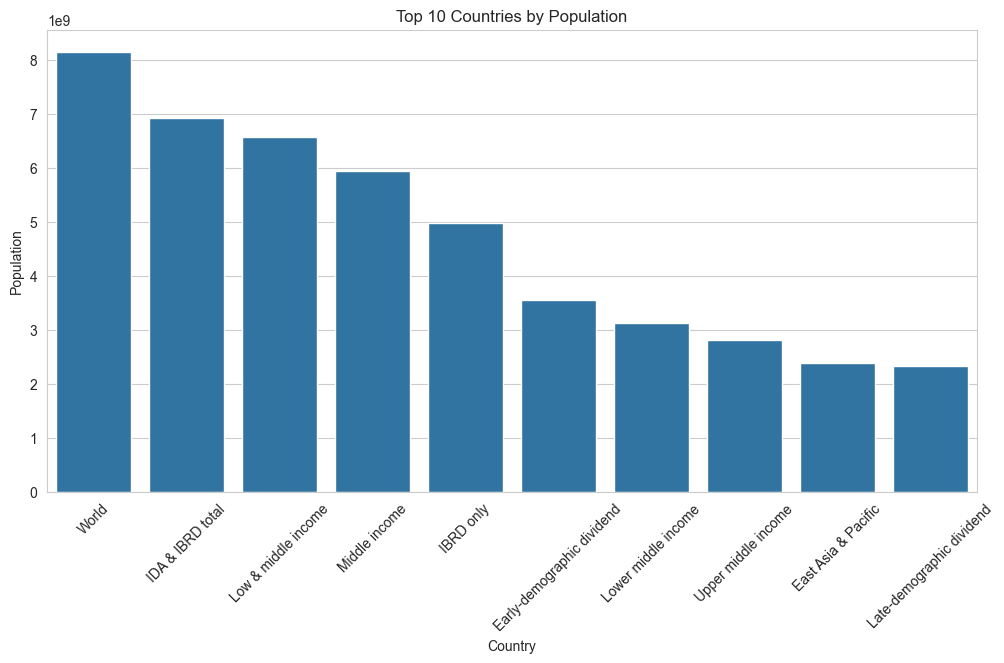

In [35]:
top10 = population_latest.head(10)

plt.figure(figsize=(12,6))

sns.barplot(x="Country Name", y=latest_year, data=top10)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Population")

plt.xlabel("Country")
plt.ylabel("Population")

plt.show()

## Key Insights

- Global population distribution is highly uneven, with a few countries accounting for a large percentage of the world's population.
- Countries such as China and India dominate global population statistics.
- Population growth trends show steady increases in developing nations over the past decades.
- The majority of countries fall into lower population ranges, while only a few countries exceed hundreds of millions.

In [36]:
population_latest.to_csv("../data/processed/population_latest.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
